# 03 — Data Preparation for LSTM Anomaly Classifier

This notebook prepares the VORAUS-AD dataset for binary anomaly classification using a sliding-window LSTM model.

## How to reproduce this notebook
1. Install dependencies:
   ```
   pip install pandas numpy scikit-learn matplotlib pyarrow
   ```
2. Place `voraus-ad-dataset-100hz.parquet` in the **project root** (`ROOT/`).
3. Run all cells top-to-bottom from this notebook's location (`ROOT/notebooks/`).

## Output artefacts
| File | Description |
|------|-------------|
| `../data/lstm_classifier/sequences.npz` | `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test` as float32 arrays |
| `../data/lstm_classifier/scaler.pkl` | Fitted `StandardScaler` (trained on training windows only) |
| `../data/lstm_classifier/config.pkl` | Window size, stride, feature count, sensor list |
| `../figures/lstm_classifier/data_class_distribution.png` | Class distribution plot across splits |

## Key design decisions
| Decision | Value | Rationale |
|----------|-------|-----------|
| Anomaly definition | `category != 12` | Category 12 is the only labelled-normal operating condition |
| Window size | 500 timesteps (5 s @ 100 Hz) | Covers a full robot motion cycle; balances context vs. sample count |
| Stride | 50 timesteps | 90 % overlap maximises training data; prevents boundary effects |
| Split unit | Sample (full run) | Avoids temporal leakage between windows of the same run |
| Split ratios | 70 / 15 / 15 (normal); 40 / 30 / 30 (anomaly) | More anomaly windows reserved for evaluation |


In [1]:
# ── CELL 1: Imports & Path Setup ─────────────────────────────────────────────
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import pickle
import matplotlib.pyplot as plt

# All paths are relative to this notebook's location (ROOT/notebooks/)
ROOT        = Path("..")
DATA_DIR    = ROOT / "data" / "lstm_classifier"
FIGURES_DIR = ROOT / "figures"/ "lstm_classifier"

DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Reproducibility
RANDOM_SEED = 14
np.random.seed(RANDOM_SEED)

print("Directories ready:")
print(f"  Data output : {DATA_DIR}")
print(f"  Figures     : {FIGURES_DIR}")


Directories ready:
  Data output : ../data/lstm_classifier
  Figures     : ../figures/lstm_classifier


---
## 1. Load Raw Data & Redefine the Anomaly Label

The dataset ships with a generic `anomaly` column, but inspecting the `category` field reveals that **category 12 is the only normal operating condition**; categories 0–11 all correspond to injected faults.

We therefore create a corrected binary label `is_anomaly`:
- `False` → category 12 (normal)
- `True`  → categories 0–11 (anomaly)


In [2]:
# ── CELL 2: Load Data & Redefine Anomaly ──────────────────────────────────────
df = pd.read_parquet(ROOT / "voraus-ad-dataset-100hz.parquet")
print(f"Dataset shape  : {df.shape}")
print(f"Columns        : {list(df.columns[:8])} ... ({df.shape[1]} total)")

METADATA_COLS = ['time', 'sample', 'anomaly', 'category', 'setting', 'action', 'active']

# Corrected binary anomaly label
df['is_anomaly'] = (df['category'] != 12)

# Timestep-level summary
print("\n── Timestep-level class distribution ──")
print(f"  Normal   (cat 12)  : {(~df['is_anomaly']).sum():>10,}")
print(f"  Anomaly  (cat 0-11): {df['is_anomaly'].sum():>10,}")

# Sample-level summary
sample_labels = df.groupby('sample')['is_anomaly'].first()
print("\n── Sample-level class distribution ──")
print(f"  Normal samples  : {(~sample_labels).sum()}")
print(f"  Anomaly samples : {sample_labels.sum()}")
print(f"  Total samples   : {len(sample_labels)}")


Dataset shape  : (2321690, 137)
Columns        : ['time', 'sample', 'anomaly', 'category', 'setting', 'action', 'active', 'robot_voltage'] ... (137 total)

── Timestep-level class distribution ──
  Normal   (cat 12)  :  1,488,328
  Anomaly  (cat 0-11):    833,362

── Sample-level class distribution ──
  Normal samples  : 1367
  Anomaly samples : 755
  Total samples   : 2122


---
## 2. Feature Selection — Sensor Columns Only

We retain only sensor columns (all columns excluding metadata) and drop any that are **constant** across the entire dataset, as they carry no discriminative information.


In [3]:
# ── CELL 3: Select Sensor Columns ─────────────────────────────────────────────
all_sensors = [col for col in df.columns if col not in METADATA_COLS + ['is_anomaly']]
print(f"Total columns     : {len(df.columns)}")
print(f"Metadata columns  : {len(METADATA_COLS)}")
print(f"Raw sensor columns: {len(all_sensors)}")

constant_sensors = [col for col in all_sensors if df[col].nunique() <= 1]
sensors = [col for col in all_sensors if col not in constant_sensors]

print(f"Constant (removed): {len(constant_sensors)}")
print(f"Sensors kept      : {len(sensors)}")
print(f"\nFirst 5 sensors   : {sensors[:5]}")
print(f"Last  5 sensors   : {sensors[-5:]}")


Total columns     : 138
Metadata columns  : 7
Raw sensor columns: 130
Constant (removed): 1
Sensors kept      : 129

First 5 sensors   : ['robot_voltage', 'robot_current', 'io_current', 'system_current', 'target_position_1']
Last  5 sensors   : ['power_motor_mech_6', 'power_load_mech_6', 'motor_voltage_6', 'supply_voltage_6', 'brake_voltage_6']


---
## 3. Sliding-Window Extraction

Each sample (a single robot run) is converted into a series of overlapping fixed-length windows.

```
Sample (L timesteps)
├─ Window 0 : t[0   : 500]
├─ Window 1 : t[50  : 550]
├─ Window 2 : t[100 : 600]
└─ ...
```

**Parameters:**
- **Window size = 500** → 5 seconds at 100 Hz; captures a full motion cycle.
- **Stride = 50** → 90 % overlap; maximises the number of training windows.

Each window inherits the binary label of its parent sample (a sample is either fully normal or fully anomalous).

**To recreate this figure** — run `extract_windows()` on any sample from the dataset with `window_size=500, stride=50`, then count the returned array's first dimension.


In [4]:
# ── CELL 4: Window Extraction Function ────────────────────────────────────────
def extract_windows(data: np.ndarray, window_size: int = 500, stride: int = 50) -> np.ndarray:
    """
    Extract overlapping windows from a univariate/multivariate time series.

    Parameters
    ----------
    data        : ndarray of shape (n_timesteps, n_features)
    window_size : number of consecutive timesteps per window
    stride      : step size between consecutive window start positions

    Returns
    -------
    windows : ndarray of shape (n_windows, window_size, n_features)
    """
    n_timesteps = len(data)
    starts = range(0, n_timesteps - window_size + 1, stride)
    windows = np.stack([data[s : s + window_size] for s in starts])
    return windows

# ── Sanity check ──────────────────────────────────────────────────────────────
sample_id  = df['sample'].iloc[0]
sample_arr = df[df['sample'] == sample_id][sensors].values
test_wins  = extract_windows(sample_arr, window_size=500, stride=50)

print(f"Sample {sample_id}:")
print(f"  Timesteps → {len(sample_arr)}")
print(f"  Windows   → {test_wins.shape[0]}  (shape {test_wins.shape})")


Sample 0:
  Timesteps → 1096
  Windows   → 12  (shape (12, 500, 129))


---
## 4. Train / Validation / Test Split

The split is performed **at sample level** to prevent temporal leakage: if the same robot run contributed windows to both training and test sets, the model could trivially memorise run-specific patterns.

| Split       | Normal | Anomaly | Rationale |
|-------------|--------|---------|-----------|
| Train       | 70 %   | 40 %    | Maximise normal training data |
| Validation  | 15 %   | 30 %    | Balanced evaluation during training |
| Test        | 15 %   | 30 %    | Held-out final evaluation |

`random_state=14` is set throughout for full reproducibility.


In [5]:
# ── CELL 5: Sample-Level Split ────────────────────────────────────────────────
sample_meta    = df.groupby('sample')['is_anomaly'].first()
normal_samples = sample_meta[~sample_meta].index.values
anomaly_samples= sample_meta[sample_meta].index.values

print(f"Normal samples  : {len(normal_samples)}")
print(f"Anomaly samples : {len(anomaly_samples)}")

# Normal: 70 / 15 / 15
train_norm, tmp_norm  = train_test_split(normal_samples,  test_size=0.30, random_state=RANDOM_SEED)
val_norm,   test_norm = train_test_split(tmp_norm, test_size=0.50, random_state=RANDOM_SEED)

# Anomaly: 40 / 30 / 30
train_anom, tmp_anom  = train_test_split(anomaly_samples, test_size=0.60, random_state=RANDOM_SEED)
val_anom,   test_anom = train_test_split(tmp_anom, test_size=0.50, random_state=RANDOM_SEED)

print("\n── Sample counts per split ──")
print(f"  Train      : {len(train_norm)} normal + {len(train_anom)} anomaly = {len(train_norm)+len(train_anom)} samples")
print(f"  Validation : {len(val_norm)} normal  + {len(val_anom)} anomaly  = {len(val_norm)+len(val_anom)} samples")
print(f"  Test       : {len(test_norm)} normal  + {len(test_anom)} anomaly  = {len(test_norm)+len(test_anom)} samples")


Normal samples  : 1367
Anomaly samples : 755

── Sample counts per split ──
  Train      : 956 normal + 302 anomaly = 1258 samples
  Validation : 205 normal  + 226 anomaly  = 431 samples
  Test       : 206 normal  + 227 anomaly  = 433 samples


---
## 5. Build Window Arrays for Each Split

For every split we iterate over its assigned samples, run `extract_windows()`, and collect the results into a single `(N, 500, n_features)` array.  Labels are inherited at sample level.


In [6]:
# ── CELL 6: Build Windows ─────────────────────────────────────────────────────
def build_windows(df, sample_ids, sensor_cols, window_size=500, stride=50):
    """
    Build (windows, labels) arrays from a list of sample IDs.

    Returns
    -------
    X : float32 ndarray of shape (n_windows, window_size, n_features)
    y : bool   ndarray of shape (n_windows,)
    """
    all_X, all_y = [], []
    for sid in sample_ids:
        mask   = df['sample'] == sid
        data   = df.loc[mask, sensor_cols].values
        label  = df.loc[mask, 'is_anomaly'].iloc[0]
        wins   = extract_windows(data, window_size, stride)
        if len(wins):
            all_X.append(wins)
            all_y.extend([label] * len(wins))
    X = np.concatenate(all_X, axis=0).astype('float32')
    y = np.array(all_y, dtype=bool)
    return X, y

print("Building windows (this may take a minute) ...")
X_train, y_train = build_windows(df, np.concatenate([train_norm, train_anom]), sensors)
X_val,   y_val   = build_windows(df, np.concatenate([val_norm,   val_anom  ]), sensors)
X_test,  y_test  = build_windows(df, np.concatenate([test_norm,  test_anom ]), sensors)

print("\n── Window counts ──")
for name, X, y in [("Train", X_train, y_train), ("Val", X_val, y_val), ("Test", X_test, y_test)]:
    print(f"  {name:5s} : {X.shape}  |  anomaly % = {y.mean():.2%}")


Building windows (this may take a minute) ...

── Window counts ──
  Train : (15489, 500, 129)  |  anomaly % = 24.49%
  Val   : (5330, 500, 129)  |  anomaly % = 53.02%
  Test  : (5363, 500, 129)  |  anomaly % = 52.96%


---
## 6. Standardisation

We fit a `StandardScaler` **exclusively on the training windows** and apply the same transformation to validation and test sets.  This ensures no information from evaluation data leaks into normalisation statistics.

Each sensor is independently standardised to zero mean and unit variance.

**Verification criterion:** after scaling, `X_train.mean() ≈ 0` and `X_train.std() ≈ 1`.


In [7]:
# ── CELL 7: Fit & Apply StandardScaler ────────────────────────────────────────
n_train, T, F = X_train.shape

scaler = StandardScaler()
scaler.fit(X_train.reshape(-1, F))                           # fit on train only

def scale_split(X, scaler, F):
    n, T, _ = X.shape
    return scaler.transform(X.reshape(-1, F)).reshape(n, T, F).astype('float32')

X_train = scale_split(X_train, scaler, F)
X_val   = scale_split(X_val,   scaler, F)
X_test  = scale_split(X_test,  scaler, F)

print("── Scaling verification ──")
print(f"  X_train  mean : {X_train.mean():.6f}  (target ≈ 0)")
print(f"  X_train  std  : {X_train.std():.6f}  (target ≈ 1)")
print(f"  X_val    mean : {X_val.mean():.6f}")
print(f"  X_test   mean : {X_test.mean():.6f}")

assert abs(X_train.mean()) < 0.01, "Scaling failed: mean out of range"
assert abs(X_train.std() - 1.0) < 0.01, "Scaling failed: std out of range"
print("\n✔ Scaling assertions passed")


── Scaling verification ──
  X_train  mean : -0.000001  (target ≈ 0)
  X_train  std  : 0.999998  (target ≈ 1)
  X_val    mean : -0.000016
  X_test   mean : -0.000564

✔ Scaling assertions passed


---
## 7. Class Distribution Visualisation

The plot below shows the number of windows per class in each split.

**To recreate this figure:** run this cell after `X_train / y_train`, `X_val / y_val`, `X_test / y_test` have been built and scaled in the cells above.  The figure is saved to `../figures/lstm_classifier/data_class_distribution.png`.


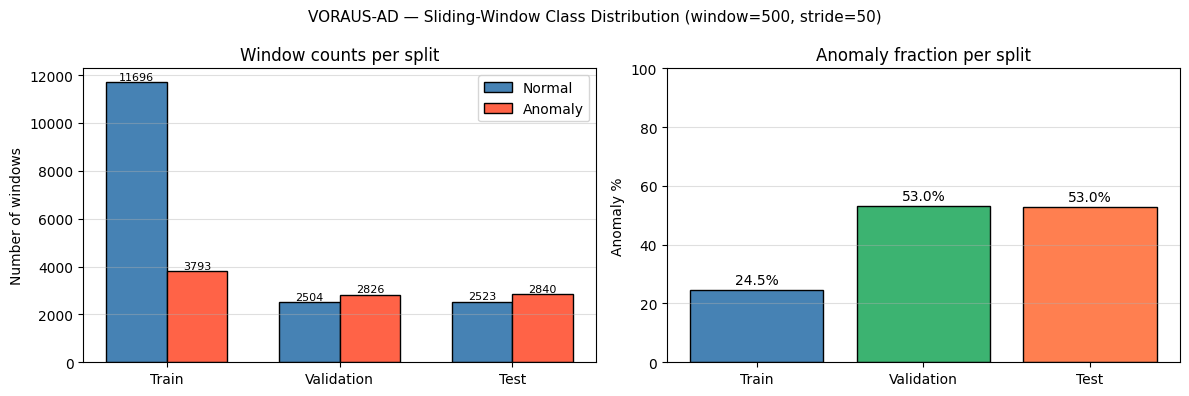

Figure saved → ../figures/lstm_classifier/data_class_distribution.png


In [8]:
# ── CELL 8: Class Distribution Figure ─────────────────────────────────────────
splits  = ['Train', 'Validation', 'Test']
ys      = [y_train, y_val, y_test]
normal  = [(~y).sum() for y in ys]
anomaly = [y.sum()    for y in ys]

x   = np.arange(len(splits))
w   = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Window counts
axes[0].bar(x - w/2, normal,  w, label='Normal',  color='steelblue',  edgecolor='black')
axes[0].bar(x + w/2, anomaly, w, label='Anomaly', color='tomato', edgecolor='black')
axes[0].set_xticks(x); axes[0].set_xticklabels(splits)
axes[0].set_ylabel('Number of windows'); axes[0].set_title('Window counts per split')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.4)
for xi, n, a in zip(x, normal, anomaly):
    axes[0].text(xi - w/2, n + 20, str(n), ha='center', va='bottom', fontsize=8)
    axes[0].text(xi + w/2, a + 20, str(a), ha='center', va='bottom', fontsize=8)

# Anomaly fraction
fracs = [y.mean() * 100 for y in ys]
axes[1].bar(splits, fracs, color=['steelblue', 'mediumseagreen', 'coral'], edgecolor='black')
axes[1].set_ylabel('Anomaly %'); axes[1].set_title('Anomaly fraction per split')
axes[1].set_ylim(0, 100); axes[1].grid(axis='y', alpha=0.4)
for xi, f in enumerate(fracs):
    axes[1].text(xi, f + 1, f'{f:.1f}%', ha='center', va='bottom', fontsize=10)

fig.suptitle('VORAUS-AD — Sliding-Window Class Distribution (window=500, stride=50)', fontsize=11)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "data_class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved → {FIGURES_DIR / 'data_class_distribution.png'}")


---
## 8. Save Processed Data

We save three artefacts to `../data/lstm_classifier/`:

| File | Contents |
|------|----------|
| `sequences.npz` | Compressed numpy archive with all six arrays |
| `scaler.pkl` | Fitted `StandardScaler` — required at inference time |
| `config.pkl` | Hyper-parameter record for reproducibility |


In [9]:
# ── CELL 9: Save Artefacts ────────────────────────────────────────────────────
# sequences.npz
np.savez_compressed(
    DATA_DIR / "sequences.npz",
    X_train=X_train, y_train=y_train,
    X_val=X_val,     y_val=y_val,
    X_test=X_test,   y_test=y_test,
)
print(f"✔ Saved sequences.npz")
print(f"    X_train : {X_train.shape}   y_train anomaly% : {y_train.mean():.2%}")
print(f"    X_val   : {X_val.shape}   y_val   anomaly% : {y_val.mean():.2%}")
print(f"    X_test  : {X_test.shape}   y_test  anomaly% : {y_test.mean():.2%}")

# scaler.pkl
with open(DATA_DIR / "scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print(f"\n✔ Saved scaler.pkl")

# config.pkl
config = {
    'window_size'      : T,
    'stride'           : 50,
    'n_features'       : F,
    'n_train_windows'  : len(X_train),
    'n_val_windows'    : len(X_val),
    'n_test_windows'   : len(X_test),
    'anomaly_def'      : 'category != 12 → is_anomaly = True',
    'sensors'          : sensors,
    'random_seed'      : RANDOM_SEED,
}
with open(DATA_DIR / "config.pkl", "wb") as f:
    pickle.dump(config, f)
print(f"\n✔ Saved config.pkl")
print(f"    n_features : {F}")
print(f"    window_size: {T},  stride: 50")


✔ Saved sequences.npz
    X_train : (15489, 500, 129)   y_train anomaly% : 24.49%
    X_val   : (5330, 500, 129)   y_val   anomaly% : 53.02%
    X_test  : (5363, 500, 129)   y_test  anomaly% : 52.96%

✔ Saved scaler.pkl

✔ Saved config.pkl
    n_features : 129
    window_size: 500,  stride: 50


---
## Summary

Data preparation is complete.  The pipeline produces:

1. **Correctly labelled binary targets** — the original `anomaly` column is replaced by `is_anomaly` derived from `category`.
2. **Leakage-free splits** — train / validation / test are partitioned at sample (run) level.
3. **Normalised windows** — each sensor is zero-mean unit-variance using statistics computed from the training set only.
4. **Serialised artefacts** — arrays, scaler, and config saved for downstream reproducibility.

The next notebook (`lstm_classifier_model.ipynb`) loads `sequences.npz` and `config.pkl` to train the LSTM classifier.

---
